# 2024 Indian Lok Sabha Election Data Analysis

## Project Overview

### This project analyzes the results of the 2024 Indian Lok Sabha Election using Python. The analysis focuses on party performance, constituency-level results, and victory margins through exploratory data analysis (EDA) and data visualization.

### **Project by:** Ashwanth Ragav H  
### **Tools Used:** Python, Pandas, NumPy, Matplotlib, Jupyter Notebook  
### **Dataset:** 2024 Indian Lok Sabha Election Results

## importing libraires


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### loading the data to the pandas dataframe and check the first five rows 

In [133]:
data = pd.read_csv("C:/Users/Ashwa/OneDrive/Documents/project final year/election data analysis/election_results_2024.csv")
df = pd.DataFrame(data)
df.head()

,Constituency,Const. No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Status
0,AJMER,13,BHAGIRATH CHOUDHARY,Bharatiya Janata Party,RAMCHANDRA CHOUDHARY,Indian National Congress,329991,Result Declared
1,ALWAR,8,BHUPENDER YADAV,Bharatiya Janata Party,LALIT YADAV,Indian National Congress,48282,Result Declared
2,AMBALA,1,VARUN CHAUDHRY,Indian National Congress,BANTO KATARIA,Bharatiya Janata Party,49036,Result Declared
3,ANANTNAG-RAJOURI,3,MIAN ALTAF AHMAD,Jammu & Kashmir National Conference,MEHBOOBA MUFTI,Jammu & Kashmir Peoples Democratic Party,281794,Result Declared
4,ARAKKONAM,7,S JAGATHRATCHAKAN,Dravida Munnetra Kazhagam,L VIJAYAN,All India Anna Dravida Munnetra Kazhagam,306559,Result Declared


### checking the number of rows and colums

In [135]:
df.shape

(543, 8)

### so there are 543 constituency and 8 attributes in the dataframe

In [138]:
df.isnull().sum()

Constituency          0
Const. No.            0
Leading Candidate     0
Leading Party         0
Trailing Candidate    1
Trailing Party        1
Margin                0
Status                0
dtype: int64

In [140]:
df["Status"].value_counts()

Status
Result Declared    542
Uncontested          1
Name: count, dtype: int64

In [142]:
uncontested_df = df.loc[df["Status"] == "Uncontested"]
uncontested_df

,Constituency,Const. No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Status
493,Surat,24,MUKESHKUMAR CHANDRAKAANT DALAL,Bharatiya Janata Party,NaN,NaN,-,Uncontested


### Out of 543 Lok Sabha constituencies, 542 had declared results while 1 constituency (Surat, Gujarat) was won uncontested. Since there was no opposing candidate, no victory margin could be calculated.

### Also the NaN in the trailing candidate and party can be replaced as not contested

In [145]:
df["Trailing Candidate"] = df["Trailing Candidate"].fillna("No Opponent")
df["Trailing Party"] = df["Trailing Party"].fillna("No Opponent")
df["Margin"] = pd.to_numeric(df["Margin"], errors="coerce")

In [151]:
df.loc[df["Status"] == "Uncontested"]

,Constituency,Const. No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Status
493,Surat,24,MUKESHKUMAR CHANDRAKAANT DALAL,Bharatiya Janata Party,No Opponent,No Opponent,NaN,Uncontested


## Renaming columns

### The original dataset uses column names such as **Leading Candidate** and **Trailing Candidate**. Since the election results have been declared for all constituencies (except one uncontested constituency), these columns are renamed to **Winner** and **Runner-up** to improve readability and make the dataset easier to interpret during analysis.

In [175]:
  df.rename(columns={
    "Leading Candidate" : "Winner Candidate",
    "Leading Party" : "Winner Party",
    "Trailing Candidate" : "Runner-up",
    "Trailing Party" : "Runner-up Party"
  },inplace = True)

In [177]:
df.head()

,Constituency,Const. No.,Winner Candidate,Winner Party,Runner-up,Runner-up Party,Margin,Status
0,AJMER,13,BHAGIRATH CHOUDHARY,Bharatiya Janata Party,RAMCHANDRA CHOUDHARY,Indian National Congress,329991.0,Result Declared
1,ALWAR,8,BHUPENDER YADAV,Bharatiya Janata Party,LALIT YADAV,Indian National Congress,48282.0,Result Declared
2,AMBALA,1,VARUN CHAUDHRY,Indian National Congress,BANTO KATARIA,Bharatiya Janata Party,49036.0,Result Declared
3,ANANTNAG-RAJOURI,3,MIAN ALTAF AHMAD,Jammu & Kashmir National Conference,MEHBOOBA MUFTI,Jammu & Kashmir Peoples Democratic Party,281794.0,Result Declared
4,ARAKKONAM,7,S JAGATHRATCHAKAN,Dravida Munnetra Kazhagam,L VIJAYAN,All India Anna Dravida Munnetra Kazhagam,306559.0,Result Declared


### checking the number of seats won by each party

### This analysis shows the number of seats won by each political party. It helps identify the dominant parties in the election.

In [182]:
party_count = df["Winner Party"].value_counts()

party_count

Winner Party
Bharatiya Janata Party                                      240
Indian National Congress                                     99
Samajwadi Party                                              37
All India Trinamool Congress                                 29
Dravida Munnetra Kazhagam                                    22
Telugu Desam                                                 16
Janata Dal (United)                                          12
Shiv Sena (Uddhav Balasaheb Thackrey)                         9
Nationalist Congress Party – Sharadchandra Pawar              8
Shiv Sena                                                     7
Independent                                                   7
Lok Janshakti Party(Ram Vilas)                                5
Communist Party of India (Marxist)                            4
Yuvajana Sramika Rythu Congress Party                         4
Rashtriya Janata Dal                                          4
Indian Union Muslim League 

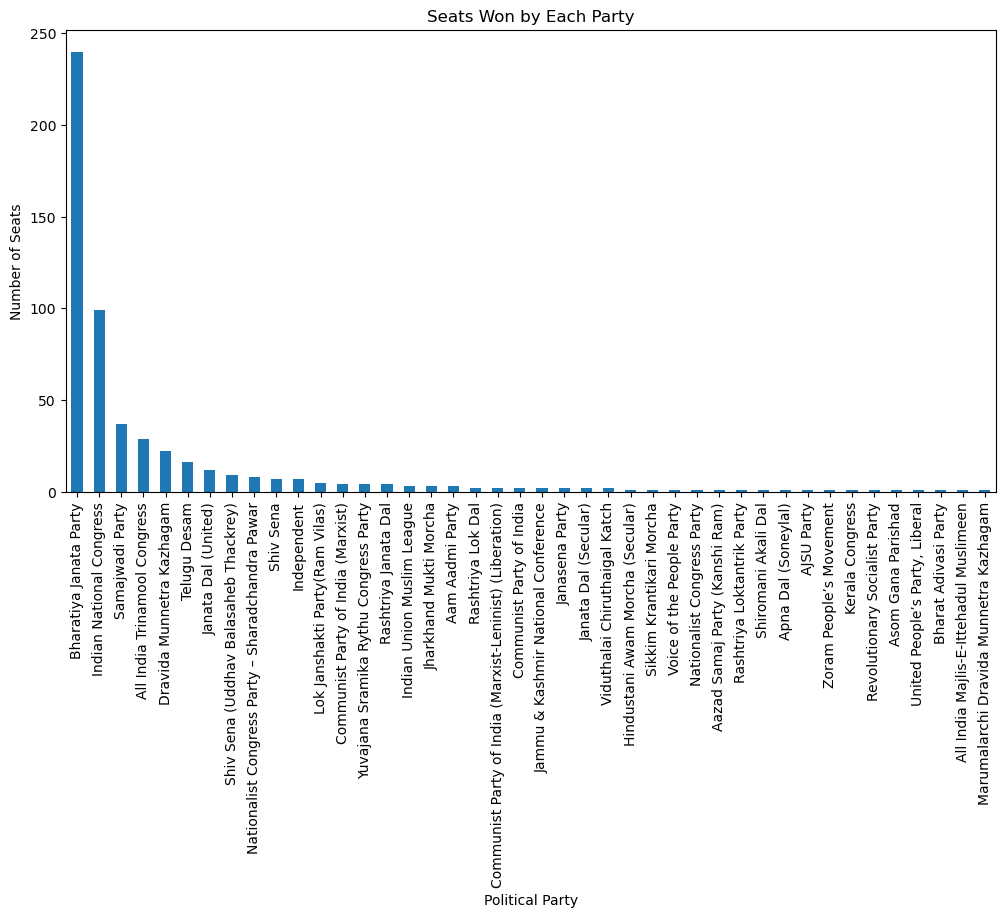

In [253]:
plt.figure(figsize=(12,6))
party_count.plot(kind="bar")

plt.title("Seats Won by Each Party")
plt.xlabel("Political Party")
plt.ylabel("Number of Seats")

plt.savefig("party_distribution.png", dpi=300)


plt.show()

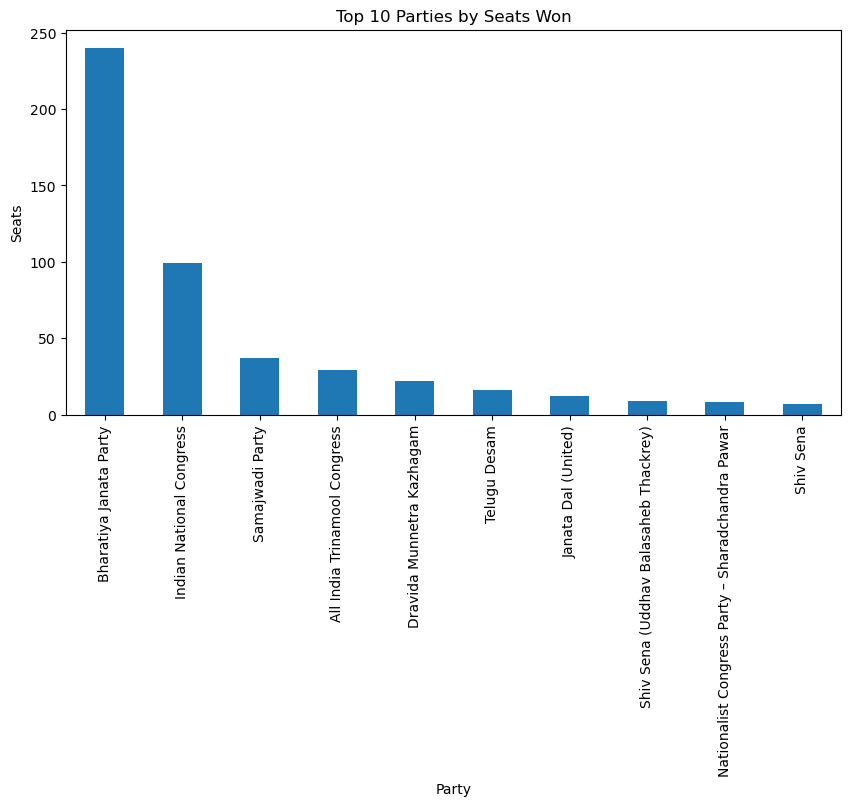

In [259]:
top10 = party_count.head(10)

plt.figure(figsize=(10,5))
top10.plot(kind="bar")

plt.title("Top 10 Parties by Seats Won")
plt.xlabel("Party")
plt.ylabel("Seats")
plt.savefig("top_10_parties_by_seat_won.png", dpi=300)

plt.show()

## Victory Margin Analysis

### Victory margin represents the difference in votes between the winning candidate and the runner-up. This analysis helps identify whether elections were closely contested or decisive.

In [197]:
df["Margin"].describe()

count    5.420000e+02
mean     1.623501e+05
std      1.472628e+05
min      4.800000e+01
25%      5.895675e+04
50%      1.222660e+05
75%      2.229720e+05
max      1.175092e+06
Name: Margin, dtype: float64

### Interpretation of Victory Margin Statistics

The summary statistics of the **Margin** column provide insights into the competitiveness of the election across constituencies.

- **Total Constituencies:** 542
- **Average Victory Margin:** Approximately **162,350 votes**
- **Median Victory Margin:** Approximately **122,266 votes**
- **Minimum Victory Margin:** **48 votes**, indicating an extremely close contest.
- **Maximum Victory Margin:** **1,175,092 votes**, indicating a highly dominant victory.
- **25% of constituencies** had victory margins below **58,957 votes**.
- **75% of constituencies** had victory margins below **222,972 votes**.

The large difference between the average (162,350) and the maximum (1,175,092), along with the high standard deviation, suggests that victory margins vary significantly across constituencies. While many elections were moderately competitive, a few constituencies recorded exceptionally large winning margins.

## Distribution of Victory Margins

### This histogram illustrates how victory margins are distributed across constituencies.

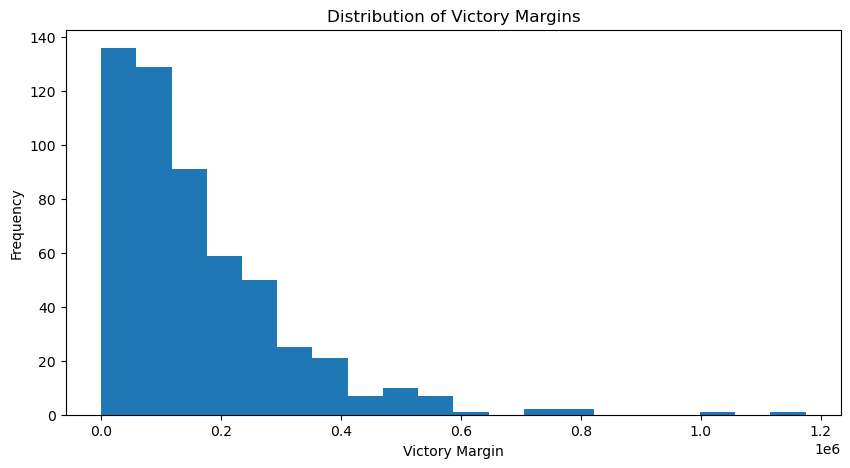

In [201]:
plt.figure(figsize=(10,5))

plt.hist(df["Margin"], bins=20)

plt.title("Distribution of Victory Margins")
plt.xlabel("Victory Margin")
plt.ylabel("Frequency")

plt.savefig("distribution_of_vi.png", dpi=300)

plt.show()

### Observation

#### Most constituencies have moderate victory margins, while a few constituencies recorded exceptionally large winning margins.

## Constituencies with the Largest Victory Margins

### This section identifies candidates who secured the most decisive victories.

In [205]:
largest_margin = df.sort_values("Margin", ascending=False)

largest_margin[["Constituency","Winner Candidate","Winner Party","Margin"]].head(10)


,Constituency,Winner Candidate,Winner Party,Margin
221,INDORE,SHANKAR LALWANI,Bharatiya Janata Party,1175092.0
157,Dhubri,RAKIBUL HUSSAIN,Indian National Congress,1012476.0
525,VIDISHA,SHIVRAJ SINGH CHOUHAN,Bharatiya Janata Party,821408.0
384,Navsari,C R PATIL,Bharatiya Janata Party,773551.0
186,Gandhinagar,AMIT SHAH,Bharatiya Janata Party,744716.0
159,Diamond harbour,ABHISHEK BANERJEE,All India Trinamool Congress,710930.0
513,Tripura West,BIPLAB KUMAR DEB,Bharatiya Janata Party,611578.0
529,Vadodara,DR. HEMANG JOSHI,Bharatiya Janata Party,582126.0
422,RAIPUR,BRIJMOHAN AGRAWAL,Bharatiya Janata Party,575285.0
503,TIRUVALLUR,Sasikanth Senthil,Indian National Congress,572155.0


## Closest Election Contests

### This analysis identifies constituencies where the winning margin was the smallest, indicating highly competitive elections.

In [212]:
closest = df.sort_values("Margin")

closest[["Constituency","Winner Candidate","Winner Party","Runner-up","Margin"]].head(10)

,Constituency,Winner Candidate,Winner Party,Runner-up,Margin
357,Mumbai North West,RAVINDRA DATTARAM WAIKAR,Shiv Sena,AMOL GAJANAN KIRTIKAR,48.0
40,Attingal,ADV ADOOR PRAKASH,Indian National Congress,V JOY,684.0
236,Jajpur,RABINDRA NARAYAN BEHERA,Bharatiya Janata Party,SARMISTHA SETHI,1587.0
226,JAIPUR RURAL,RAO RAJENDRA SINGH,Bharatiya Janata Party,ANIL CHOPRA,1615.0
256,KANKER,BHOJRAJ NAG,Bharatiya Janata Party,BIRESH THAKUR,1884.0
125,Chandigarh,MANISH TEWARI,Indian National Congress,SANJAY TANDON,2504.0
207,Hamirpur,AJENDRA SINGH LODHI,Samajwadi Party,KUNWAR PUSHPENDRA SINGH CHANDEL,2629.0
312,Lakshadweep,MUHAMMED HAMDULLAH SAYEED,Indian National Congress,MOHAMMED FAIZAL PP,2647.0
175,Farrukhabad,MUKESH RAJPUT,Bharatiya Janata Party,DR. NAVAL KISHOR SHAKYA,2678.0
74,Bansgaon,KAMLESH PASWAN,Bharatiya Janata Party,SADAL PRASAD,3150.0


## Most Frequent Winner and Runner-up Parties

### This analysis compares how frequently each political party appeared as the winner and as the runner-up.

In [225]:
winner = df["Winner Party"].value_counts()

runner = df["Runner-up Party"].value_counts()

winner

Winner Party
Bharatiya Janata Party                                      240
Indian National Congress                                     99
Samajwadi Party                                              37
All India Trinamool Congress                                 29
Dravida Munnetra Kazhagam                                    22
Telugu Desam                                                 16
Janata Dal (United)                                          12
Shiv Sena (Uddhav Balasaheb Thackrey)                         9
Nationalist Congress Party – Sharadchandra Pawar              8
Shiv Sena                                                     7
Independent                                                   7
Lok Janshakti Party(Ram Vilas)                                5
Communist Party of India (Marxist)                            4
Yuvajana Sramika Rythu Congress Party                         4
Rashtriya Janata Dal                                          4
Indian Union Muslim League 

In [227]:
runner

Runner-up Party
Indian National Congress                                    167
Bharatiya Janata Party                                      153
All India Anna Dravida Munnetra Kazhagam                     24
Samajwadi Party                                              24
Biju Janata Dal                                              21
Yuvajana Sramika Rythu Congress Party                        21
Rashtriya Janata Dal                                         18
Communist Party of India (Marxist)                           17
All India Trinamool Congress                                 13
Aam Aadmi Party                                              13
Shiv Sena (Uddhav Balasaheb Thackrey)                        10
Shiv Sena                                                     8
Independent                                                   5
Communist Party of India                                      4
Janata Dal (United)                                           4
Nationalist Congress Par

## Election Status

### This section summarizes the status of election results across all constituencies.

In [230]:
df["Status"].value_counts()

Status
Result Declared    542
Uncontested          1
Name: count, dtype: int64

## Number of Unique Constituencies

### This analysis determines the total number of unique parliamentary constituencies present in the dataset. Verifying the number of constituencies helps ensure the completeness of the election data and confirms that each constituency is represented only once.

In [244]:
df["Constituency"].nunique()

541

### The dataset contains **541 unique parliamentary constituencies**. This indicates that the dataset does not include all Lok Sabha constituencies or that some constituency records may be missing or duplicated

In [240]:
print("Total rows:", len(df))
print("Unique constituencies:", df["Constituency"].nunique())
print("Duplicate constituencies:", df["Constituency"].duplicated().sum())

Total rows: 543
Unique constituencies: 541
Duplicate constituencies: 2


In [242]:
df[df["Constituency"].duplicated(keep=False)].sort_values("Constituency")

,Constituency,Const. No.,Winner Candidate,Winner Party,Runner-up,Runner-up Party,Margin,Status
41,Aurangabad,19,BHUMARE SANDIPANRAO ASARAM,Shiv Sena,IMTIAZ JALEEL SYED,All India Majlis-E-Ittehadul Muslimeen,134650.0,Result Declared
42,Aurangabad,37,ABHAY KUMAR SINHA,Rashtriya Janata Dal,SUSHIL KUMAR SINGH,Bharatiya Janata Party,79111.0,Result Declared
332,Maharajganj,63,PANKAJ CHAUDHARY,Bharatiya Janata Party,VIRENDRA CHAUDHARY,Indian National Congress,35451.0,Result Declared
333,Maharajganj,19,"JANARDAN SINGH ""SIGRIWAL""",Bharatiya Janata Party,AAKASH KUMAR SINGH,Indian National Congress,102651.0,Result Declared


## Observation

### The dataset contains **543 parliamentary election records**. Although only **541 unique constituency names** are present, this is expected because some constituency names (such as **Aurangabad** and **Maharajganj**) occur in different states. Since the dataset does not include a **State** column, these distinct constituencies share the same name and are counted only once when considering constituency names alone.

# Key Findings

## - Bharatiya Janata Party secured the majority of constituencies.
## - Victory margins varied significantly across constituencies.
## - Some constituencies witnessed highly competitive elections with very narrow margins.
## - Other constituencies experienced decisive victories with large vote differences.
## - The comparison between winners and runner-up parties provides insights into electoral competition.

In [255]:
import os

print(os.getcwd())

C:\Users\Ashwa
